# Traversal Quality Analysis by Port-to-Port Category

Analyzes the quality of graph traversals across all sessions, broken down by which port-to-port path each trial represents.

**Metrics per (Port_from → Port_to) category:**
1. **Violations** – illegal transitions (non-adjacent node/edge jumps) computed inline from `traversal_df.csv` via the augmented graph `G_aug`
2. **Inferred steps** – corrected/filled-in steps in `improved_traversal_df.csv` (`is_inferred=True`)
3. **Path efficiency** – actual path length vs. expected shortest path
4. **Path type** – direct vs. indirect (detour)
5. **Missing nodes** – nodes on the shortest graph path that were never visited

> **Note:** Violations are now computed directly from `traversal_df.csv` (same `G_aug` logic as the fixer), replacing the stale `traversal_violations.csv` which was generated by a separate old pipeline. Run `traversal_pipeline.ipynb` first to regenerate `traversal_df.csv` for all sessions.

In [44]:
import os
import ast
import pickle
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

BASE_DIR = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs')
GRAPH_PKL = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/FullMazeGrid.pkl')

PORTS = list(range(1, 9))  # Port1 to Port8

## 1. Build the Graph

In [45]:
with open(GRAPH_PKL, 'rb') as f:
    maze_data = pickle.load(f)

G = nx.Graph()
for edge_key in maze_data['mappings']['edges'].keys():
    a, b = edge_key.split('_')
    G.add_edge(a, b)

print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Is tree: {nx.is_tree(G)}')

leaf_nodes = [n for n in G.nodes() if G.degree(n) == 1]
print(f'Leaf nodes (ports): {len(leaf_nodes)}')

Graph: 126 nodes, 125 edges
Is tree: True
Leaf nodes (ports): 64


In [46]:
# Build augmented graph (G_aug) — same construction as ImprovedMazeTraversalFixer.
# Physical corridor edges become intermediate tuple-state nodes;
# virtual leaf↔parent edges stay as direct node-node connections.
# Used for inline violation detection instead of the stale traversal_violations.csv.

def _is_virtual_edge(u_str: str, v_str: str) -> bool:
    def level(s):
        return s[1] if len(s) >= 2 and s[0] in ('L', 'R') else None
    l_u, l_v = level(str(u_str)), level(str(v_str))
    return bool(l_u and l_v and {l_u, l_v} == {'4', '5'})

G_aug = nx.Graph()
for u in G.nodes():
    G_aug.add_node(str(u), state_type='node')
for u, v in G.edges():
    u_s, v_s = str(u), str(v)
    if G.degree(u) == 1 or G.degree(v) == 1 or _is_virtual_edge(u_s, v_s):
        G_aug.add_edge(u_s, v_s)
    else:
        edge_state = tuple(sorted((u_s, v_s)))
        G_aug.add_node(edge_state, state_type='edge')
        G_aug.add_edge(u_s, edge_state)
        G_aug.add_edge(v_s, edge_state)

print(f'Augmented graph: {G_aug.number_of_nodes()} nodes, {G_aug.number_of_edges()} edges')
print('(Physical corridor edges → intermediate tuple-state; virtual leaf↔parent → direct edge)')

Augmented graph: 187 nodes, 186 edges
(Physical corridor edges → intermediate tuple-state; virtual leaf↔parent → direct edge)


In [47]:
# Virtual edges: leaf-to-parent pairs with no physical maze corridor.
# In traversal_df these appear as consecutive node→node rows (no edge row between them).
# The violations.csv already excludes these — but the missing-edge check must be updated.
leaf_nodes_set = set(leaf_nodes)  # leaf_nodes defined in the graph cell above
virtual_edges = set()
for leaf in leaf_nodes_set:
    parent = list(G.neighbors(leaf))[0]
    virtual_edges.add((leaf, parent))
    virtual_edges.add((parent, leaf))

leaf_to_parent = {leaf: list(G.neighbors(leaf))[0] for leaf in leaf_nodes_set}

print(f'Leaf nodes with no physical corridor to parent: {len(leaf_nodes_set)}')
print(f'Virtual edge pairs (leaf ↔ parent, no corridor): {len(virtual_edges) // 2}')
print()
print('Port nodes → virtual edge connections:')
# (port_to_node defined later in Section 4; shown here for reference after running all cells)
_sample_virt = {k: v for k, v in leaf_to_parent.items() if any(k in str(x) or v in str(x) for x in [])}
for leaf, parent in list(leaf_to_parent.items())[:6]:
    print(f'  {leaf} ↔ {parent}')

Leaf nodes with no physical corridor to parent: 64
Virtual edge pairs (leaf ↔ parent, no corridor): 64

Port nodes → virtual edge connections:
  R56 ↔ R43
  L515 ↔ L47
  L54 ↔ L42
  R51 ↔ R40
  R525 ↔ R412
  R524 ↔ R412


## 1a. Virtual Edges (No Physical Maze Corridor)
Between each **leaf node** (L5XX/R5XX) and its **parent** (L4XX/R4XX) there is no physical corridor in the maze. The animal jumps directly between them, so the traversal data shows a **node→node** transition with no intervening edge row.

Implications for this analysis:
- The **violations detector already correctly excludes** these expected node→node transitions — no change needed there.
- The **missing-edges calculation must use node→node pairs** (not edge rows) when checking whether a virtual edge was traversed.

In [ ]:
def _parse_trav_state(row):
    """Extract the G_aug state (str node or sorted tuple edge) from a traversal_df row."""
    lt = row.get('location_type', '')
    if lt == 'node':
        return row.get('headstage_graph_node')
    s = row.get('headstage_graph_edge')
    if s is None:
        return None
    try:
        if pd.isna(s):
            return None
    except (TypeError, ValueError):
        pass
    if isinstance(s, str) and s.startswith('('):
        try:
            s = ast.literal_eval(s)
        except Exception:
            pass
    if isinstance(s, list):
        s = tuple(s)
    return s


def compute_violations_df(trav: pd.DataFrame) -> pd.DataFrame:
    """Compute invalid G_aug transitions directly from traversal_df.
    Replaces stale traversal_violations.csv (which was from a separate old pipeline).
    Requires traversal_df to have: location_type, start_frame_global, trial_idx columns.
    """
    _cols = ['from', 'from_type', 'to', 'to_type', 'from_frame', 'to_frame']
    _empty = pd.DataFrame(columns=_cols)
    required = {'location_type', 'start_frame_global', 'trial_idx'}
    if trav.empty or not required.issubset(trav.columns):
        return _empty

    records = []
    trav_s = trav.sort_values('start_frame_global').reset_index(drop=True)
    for i in range(len(trav_s) - 1):
        r1, r2 = trav_s.iloc[i], trav_s.iloc[i + 1]
        if r1['trial_idx'] != r2['trial_idx']:
            continue
        s1, s2 = _parse_trav_state(r1), _parse_trav_state(r2)
        # Skip rows with missing state
        try:
            if s1 is None or (not isinstance(s1, tuple) and pd.isna(s1)):
                continue
            if s2 is None or (not isinstance(s2, tuple) and pd.isna(s2)):
                continue
        except (TypeError, ValueError):
            pass
        if s1 not in G_aug or s2 not in G_aug or (s1 != s2 and not G_aug.has_edge(s1, s2)):
            records.append({
                'from':       str(s1),
                'from_type':  r1['location_type'],
                'to':         str(s2),
                'to_type':    r2['location_type'],
                'from_frame': r1['start_frame_global'],
                'to_frame':   r2['start_frame_global'],
            })
    return pd.DataFrame(records, columns=_cols) if records else _empty


def load_session(session_dir: Path):
    """Load all relevant files for one session. Returns dict or None if missing required files."""
    required = ['traversal_df.csv', 'reward_df_annotated.csv']
    for f in required:
        if not (session_dir / f).exists():
            return None

    trav   = pd.read_csv(session_dir / 'traversal_df.csv')
    reward = pd.read_csv(session_dir / 'reward_df_annotated.csv')

    # Compute violations inline from traversal_df (replaces stale traversal_violations.csv).
    # Requires traversal_df regenerated by traversal_pipeline.ipynb (needs location_type,
    # start_frame_global columns). Falls back to empty if old-format file is detected.
    viol = compute_violations_df(trav)

    imp_trav = None
    if (session_dir / 'improved_traversal_df.csv').exists():
        imp_trav = pd.read_csv(session_dir / 'improved_traversal_df.csv')

    # Load summary_df for frame→trial mapping (needed to map violations to trials)
    summ = pd.read_csv(session_dir / 'summary_df.csv', low_memory=False)
    summ_clean = summ.dropna(subset=['frame_idx_global', 'trial_idx']).copy()
    summ_clean['frame_idx_global'] = summ_clean['frame_idx_global'].astype(int)
    summ_clean['trial_idx']        = summ_clean['trial_idx'].astype(int)
    frame_to_trial = summ_clean.set_index('frame_idx_global')['trial_idx'].to_dict()

    return dict(trav=trav, viol=viol, reward=reward, imp_trav=imp_trav, frame_to_trial=frame_to_trial)


sessions = {}
for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir():
        continue
    data = load_session(d)
    if data is not None:
        sessions[d.name] = data
        print(f'Loaded {d.name}: {len(data["trav"])} traversal rows, '
              f'{len(data["viol"])} violations (inline), {len(data["reward"])} trials')
    else:
        print(f'Skipped {d.name} (missing required files)')

print(f'\nTotal sessions loaded: {len(sessions)}')

## 3. Build Per-Trial Summary with Port-to-Port Labels

In [ ]:
def build_trial_df(session_name: str, data: dict) -> pd.DataFrame:
    """Return a per-trial DataFrame with port_from, port_to, path quality metrics, violation counts, and inferred counts."""
    reward = data['reward'].copy()
    trav = data['trav']
    viol = data['viol'].copy()
    imp_trav = data['imp_trav']
    frame_to_trial = data['frame_to_trial']

    # --- Port categorization ---
    # trial N: path is from reward_port[N-1] to reward_port[N]
    reward = reward.sort_values('trial_idx').reset_index(drop=True)
    reward['port_from'] = reward['reward_port'].shift(1)
    reward['port_to'] = reward['reward_port']
    reward['port_from'] = reward['port_from'].astype(pd.Int64Dtype())
    reward['port_to'] = reward['port_to'].astype(pd.Int64Dtype())
    reward['path_category'] = reward.apply(
        lambda r: f'Port{int(r.port_from)}→Port{int(r.port_to)}'
        if pd.notna(r.port_from) else None, axis=1
    )
    reward['same_port'] = (reward['port_from'] == reward['port_to'])

    # --- Violation counts per trial ---
    viol_counts = pd.Series(dtype=int, name='n_violations')
    viol_by_type = pd.DataFrame()
    if len(viol) > 0 and 'from_frame' in viol.columns and 'from_type' in viol.columns:
        viol['trial_idx'] = viol['from_frame'].map(frame_to_trial)
        viol['viol_type'] = viol['from_type'] + '→' + viol['to_type']
        viol_counts = viol.groupby('trial_idx').size().rename('n_violations')
        viol_by_type = viol.groupby(['trial_idx', 'viol_type']).size().unstack(fill_value=0)
        viol_by_type.columns = [f'viol_{c}' for c in viol_by_type.columns]

    # --- Inferred step counts per trial ---
    inferred_counts = pd.Series(dtype=int, name='n_inferred')
    total_step_counts = pd.Series(dtype=int, name='n_total_steps')
    if imp_trav is not None:
        imp = imp_trav.copy()
        imp['trial_idx'] = imp['start_frame'].map(frame_to_trial)
        inferred_counts = imp[imp['is_inferred'] == True].groupby('trial_idx').size().rename('n_inferred')
        total_step_counts = imp.groupby('trial_idx').size().rename('n_total_steps')

    # --- Path quality from reward_df ---
    quality_cols = [
        'trial_idx', 'reward_port_transition_type_chain',
        'reward_port_transition_length_sum', 'reward_port_expected_shortest_length',
        'reward_port_transition_match_trial_idx'
    ]
    available_quality = [c for c in quality_cols if c in reward.columns]
    quality = reward[available_quality].copy() if available_quality else None

    # --- Assemble per-trial df ---
    trial_df = reward[['trial_idx', 'port_from', 'port_to', 'path_category', 'same_port',
                        'reward_port', 'reward_time']].copy()
    trial_df = trial_df.join(viol_counts, on='trial_idx', how='left')
    if not viol_by_type.empty:
        trial_df = trial_df.join(viol_by_type, on='trial_idx', how='left')
    trial_df = trial_df.join(inferred_counts, on='trial_idx', how='left')
    trial_df = trial_df.join(total_step_counts, on='trial_idx', how='left')

    # Path quality: the transition described in row N (shift) is completed at 'match_trial'
    if quality is not None and 'reward_port_transition_length_sum' in quality.columns:
        q = quality.copy()
        q = q.rename(columns={
            'reward_port_transition_type_chain': 'path_type',
            'reward_port_transition_length_sum': 'path_length_actual',
            'reward_port_expected_shortest_length': 'path_length_shortest'
        })
        q['path_efficiency'] = q['path_length_actual'] / q['path_length_shortest']
        q['match_trial'] = q['reward_port_transition_match_trial_idx'].astype(pd.Int64Dtype())

        # Assign quality to the trial that completed the path
        q_valid = q.dropna(subset=['match_trial', 'path_length_actual'])
        q_valid = q_valid.set_index('match_trial')[['path_type', 'path_length_actual',
                                                      'path_length_shortest', 'path_efficiency']]
        trial_df = trial_df.join(q_valid, on='trial_idx', how='left')

    trial_df['n_violations'] = trial_df['n_violations'].fillna(0).astype(int)
    trial_df['n_inferred'] = trial_df['n_inferred'].fillna(0).astype(int)
    trial_df['n_total_steps'] = trial_df['n_total_steps'].fillna(0).astype(int)
    trial_df['session'] = session_name

    return trial_df


all_trials = []
for name, data in sessions.items():
    df = build_trial_df(name, data)
    all_trials.append(df)

trials = pd.concat(all_trials, ignore_index=True)
print(f'Total trials across all sessions: {len(trials)}')
print(f'Columns: {trials.columns.tolist()}')

Total trials across all sessions: 8365
Columns: ['trial_idx', 'port_from', 'port_to', 'path_category', 'same_port', 'reward_port', 'reward_time', 'n_violations', 'viol_edge→edge', 'viol_edge→node', 'viol_node→edge', 'viol_node→node', 'n_inferred', 'n_total_steps', 'path_type', 'path_length_actual', 'path_length_shortest', 'path_efficiency', 'session']


In [ ]:
# Filter to non-same-port trials with known port_from
valid_trials = trials[trials['path_category'].notna() & ~trials['same_port']].copy()
same_port_trials = trials[trials['same_port'] == True].copy()

print(f'Trials with distinct port-to-port path: {len(valid_trials)}')
print(f'Same-port re-visit trials: {len(same_port_trials)}')
print(f'Trials with unknown from_port (first of session): {trials["path_category"].isna().sum()}')
print()
print('Path category counts (top 20):')
print(valid_trials['path_category'].value_counts().head(20).to_string())

Trials with distinct port-to-port path: 5997
Same-port re-visit trials: 2356
Trials with unknown from_port (first of session): 12

Path category counts (top 20):
path_category
Port2→Port1    694
Port1→Port2    601
Port7→Port8    586
Port5→Port6    540
Port4→Port3    459
Port8→Port7    418
Port6→Port5    416
Port3→Port4    370
Port2→Port7    279
Port8→Port2    190
Port7→Port2    130
Port6→Port2    112
Port2→Port4     80
Port1→Port7     77
Port2→Port8     71
Port4→Port5     69
Port5→Port2     65
Port6→Port4     63
Port2→Port5     59
Port3→Port5     53


## 4. Port-to-Node Mapping
Identify which graph node corresponds to each port number.

In [ ]:
def get_port_to_node_for_session(session_name: str) -> dict:
    """
    Return port→node mapping for a session based on its date.
    Session name format: DD_MM_YYYY.
    Ports 7 and 8 swapped on/after 07/09/2025.
    """
    parts = session_name.split('_')
    DD, MM = parts[0], parts[1]

    port_map = {
        1: 'R522', 2: 'R526',
        3: 'L56',  4: 'L510',
        5: 'L521', 6: 'L525',
    }
    if MM == '09' and DD in {'07', '08', '09', '10', '11'}:
        port_map[7] = 'R59'
        port_map[8] = 'R55'
    else:
        port_map[7] = 'R55'
        port_map[8] = 'R59'
    return port_map


print('Port → Node mapping by session:')
for session_name in sorted(sessions.keys()):
    p2n = get_port_to_node_for_session(session_name)
    print(f'  {session_name}: Port7={p2n[7]}, Port8={p2n[8]}')

# Sanity-check: confirm all nodes are in the graph
sample = get_port_to_node_for_session(sorted(sessions.keys())[0])
for port, node in sample.items():
    in_g = node in G.nodes()
    print(f'  Port{port} → {node}  (in graph: {in_g})')

Port → Node mapping by session:
  09_09_2025: Port7=R59, Port8=R55
  10_09_2025: Port7=R59, Port8=R55
  11_09_2025: Port7=R59, Port8=R55
  12_08_2025: Port7=R55, Port8=R59
  13_08_2025: Port7=R55, Port8=R59
  14_08_2025: Port7=R55, Port8=R59
  18_08_2025: Port7=R55, Port8=R59
  19_08_2025: Port7=R55, Port8=R59
  20_08_2025: Port7=R55, Port8=R59
  21_08_2025: Port7=R55, Port8=R59
  24_08_2025: Port7=R55, Port8=R59
  27_08_2025: Port7=R55, Port8=R59
  Port1 → R522  (in graph: True)
  Port2 → R526  (in graph: True)
  Port3 → L56  (in graph: True)
  Port4 → L510  (in graph: True)
  Port5 → L521  (in graph: True)
  Port6 → L525  (in graph: True)
  Port7 → R59  (in graph: True)
  Port8 → R55  (in graph: True)


## 5. Missing Nodes Analysis
For each trial, compute the shortest path between the two port nodes and count how many shortest-path nodes were never visited.

In [ ]:
def compute_shortest_paths_for_port_map(port_to_node: dict) -> dict:
    """Compute all-pairs shortest paths between port nodes for a given port→node mapping."""
    valid = {p: n for p, n in port_to_node.items() if n and n in G.nodes()}
    sp = {}
    for p1, n1 in valid.items():
        for p2, n2 in valid.items():
            if p1 != p2:
                try:
                    sp[(p1, p2)] = nx.shortest_path(G, n1, n2)
                except nx.NetworkXNoPath:
                    pass
    return sp


# Pre-compute shortest paths for each distinct port map variant (ports 7/8 differ by date)
_map_after  = {1:'R522',2:'R526',3:'L56',4:'L510',5:'L521',6:'L525',7:'R59',8:'R55'}
_map_before = {1:'R522',2:'R526',3:'L56',4:'L510',5:'L521',6:'L525',7:'R55',8:'R59'}
sp_after_switch  = compute_shortest_paths_for_port_map(_map_after)
sp_before_switch = compute_shortest_paths_for_port_map(_map_before)

# Map each session to its shortest-path table
session_shortest_paths = {}
session_port_to_node = {}
for session_name in sessions:
    p2n = get_port_to_node_for_session(session_name)
    session_port_to_node[session_name] = p2n
    session_shortest_paths[session_name] = sp_after_switch if p2n[7] == 'R59' else sp_before_switch

print(f'Shortest paths computed ({len(sp_after_switch)} pairs per variant)')
print('\nSample paths (after-switch variant):')
for (p1, p2), path in list(sp_after_switch.items())[:4]:
    print(f'  Port{p1} → Port{p2}: length={len(path)-1}, path={path}')

Shortest paths computed (56 pairs per variant)

Sample paths (after-switch variant):
  Port1 → Port2: length=8, path=['R522', 'R411', 'R35', 'R22', 'R11', 'R23', 'R36', 'R413', 'R526']
  Port1 → Port3: length=11, path=['R522', 'R411', 'R35', 'R22', 'R11', 'R0', 'L0', 'L10', 'L20', 'L31', 'L43', 'L56']
  Port1 → Port4: length=11, path=['R522', 'R411', 'R35', 'R22', 'R11', 'R0', 'L0', 'L10', 'L21', 'L32', 'L45', 'L510']
  Port1 → Port5: length=11, path=['R522', 'R411', 'R35', 'R22', 'R11', 'R0', 'L0', 'L11', 'L22', 'L35', 'L410', 'L521']


In [ ]:
def compute_missing_nodes_for_session(session_name: str, data: dict, shortest_paths: dict) -> pd.DataFrame:
    """
    For each trial, compute how many nodes/edges from the expected shortest path
    were NOT visited/traversed.

    Virtual edges (leaf↔parent, no physical corridor) appear as consecutive node→node
    rows in traversal_df — NOT as edge rows. They are tracked separately.

    `shortest_paths` must be the session-specific dict (handles port7/8 date-swap).
    """
    trav = data['trav']
    reward = data['reward'].sort_values('trial_idx').reset_index(drop=True)
    reward['port_from'] = reward['reward_port'].shift(1)
    reward['port_to'] = reward['reward_port']

    results = []
    for _, row in reward.iterrows():
        trial_idx = int(row['trial_idx'])
        p_from = row['port_from']
        p_to = row['port_to']

        _nan_row = {'trial_idx': trial_idx, 'n_missing_nodes': np.nan,
                    'n_missing_regular_edges': np.nan, 'n_missing_virtual_edges': np.nan,
                    'n_missing_edges': np.nan, 'n_extra_nodes': np.nan,
                    'n_sp_nodes': np.nan, 'n_visited_nodes': np.nan,
                    'frac_sp_nodes_covered': np.nan}

        if pd.isna(p_from) or p_from == p_to:
            results.append(_nan_row)
            continue

        key = (int(p_from), int(p_to))
        if key not in shortest_paths:
            results.append(_nan_row)
            continue

        sp_nodes = set(shortest_paths[key])
        sp_edges = set(zip(shortest_paths[key][:-1], shortest_paths[key][1:]))
        sp_edges |= {(b, a) for a, b in sp_edges}  # make undirected

        trial_rows = trav[trav['trial_idx'] == trial_idx]
        visited_nodes = set(trial_rows.dropna(subset=['headstage_graph_node'])['headstage_graph_node'].unique())

        # Physical (regular) edges: detected from edge rows in traversal_df
        visited_edge_strs = trial_rows.dropna(subset=['headstage_graph_edge'])['headstage_graph_edge'].unique()
        visited_edges = set()
        for es in visited_edge_strs:
            try:
                tup = ast.literal_eval(es)
                visited_edges.add(tuple(tup))
                visited_edges.add((tup[1], tup[0]))
            except Exception:
                pass

        # Virtual edges: detected from consecutive node→node rows (no physical corridor)
        trial_rows_sorted = trial_rows.sort_values('start_frame_global')
        visited_virtual_edges = set()
        prev_node = None
        prev_was_node = False
        for _, trow in trial_rows_sorted.iterrows():
            lt = trow.get('location_type', '')
            if lt == 'node':
                curr = trow.get('headstage_graph_node')
                if pd.notna(curr):
                    if prev_was_node and prev_node is not None and prev_node != curr:
                        pair = (prev_node, curr)
                        if pair in virtual_edges or (curr, prev_node) in virtual_edges:
                            visited_virtual_edges.add(pair)
                            visited_virtual_edges.add((curr, prev_node))
                    prev_node = curr
                prev_was_node = True
            elif lt == 'edge':
                prev_was_node = False

        # Partition shortest-path edges into virtual (no corridor) and regular (physical)
        sp_virtual_edges = {e for e in sp_edges if e in virtual_edges}
        sp_regular_edges = sp_edges - sp_virtual_edges

        missing_nodes = sp_nodes - visited_nodes
        missing_virtual_directed = {e for e in (sp_virtual_edges - visited_virtual_edges) if e[0] < e[1]}
        missing_regular_directed = {e for e in (sp_regular_edges - visited_edges) if e[0] < e[1]}
        extra_nodes = visited_nodes - sp_nodes

        results.append({
            'trial_idx': trial_idx,
            'n_missing_nodes': len(missing_nodes),
            'n_missing_regular_edges': len(missing_regular_directed),
            'n_missing_virtual_edges': len(missing_virtual_directed),
            'n_missing_edges': len(missing_regular_directed) + len(missing_virtual_directed),
            'n_extra_nodes': len(extra_nodes),
            'n_sp_nodes': len(sp_nodes),
            'n_visited_nodes': len(visited_nodes),
            'frac_sp_nodes_covered': len(sp_nodes - missing_nodes) / len(sp_nodes) if sp_nodes else np.nan
        })

    return pd.DataFrame(results)


missing_dfs = []
for name, data in sessions.items():
    mdf = compute_missing_nodes_for_session(name, data, session_shortest_paths[name])
    mdf['session'] = name
    missing_dfs.append(mdf)

missing_df = pd.concat(missing_dfs, ignore_index=True)

# Merge into trials
trials = trials.merge(missing_df, on=['trial_idx', 'session'], how='left')

# Rebuild valid_trials after merge
valid_trials = trials[trials['path_category'].notna() & ~trials['same_port']].copy()
print(f'Missing node/edge analysis complete. Valid trials: {len(valid_trials)}')
print(valid_trials[['path_category', 'n_missing_nodes', 'n_missing_regular_edges',
                     'n_missing_virtual_edges', 'n_extra_nodes']].describe().round(2))

Missing node/edge analysis complete. Valid trials: 5997
       n_missing_nodes  n_missing_regular_edges  n_missing_virtual_edges  \
count          5997.00                  5997.00                  5997.00   
mean              3.43                     1.93                     1.04   
std               2.14                     1.70                     0.56   
min               0.00                     0.00                     0.00   
25%               2.00                     0.00                     1.00   
50%               4.00                     2.00                     1.00   
75%               5.00                     3.00                     1.00   
max               9.00                     6.00                     2.00   

       n_extra_nodes  
count        5997.00  
mean            0.99  
std             1.92  
min             0.00  
25%             0.00  
50%             0.00  
75%             1.00  
max            17.00  


## 6. Per-Category Summary Statistics

In [ ]:
def agg_by_category(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate all quality metrics by (port_from, port_to) pair."""
    viol_type_cols = [c for c in df.columns if c.startswith('viol_')]
    agg_dict = {
        'trial_idx': 'count',
        'n_violations': ['sum', 'mean'],
        'n_inferred': ['sum', 'mean'],
        'n_total_steps': 'mean',
        'n_missing_nodes': 'mean',
        'n_missing_regular_edges': 'mean',
        'n_missing_virtual_edges': 'mean',
        'n_missing_edges': 'mean',
        'n_extra_nodes': 'mean',
        'frac_sp_nodes_covered': 'mean',
    }
    if 'path_efficiency' in df.columns:
        agg_dict['path_efficiency'] = 'mean'
    if 'path_length_actual' in df.columns:
        agg_dict['path_length_actual'] = 'mean'
    if 'path_length_shortest' in df.columns:
        agg_dict['path_length_shortest'] = 'mean'
    for c in viol_type_cols:
        agg_dict[c] = ['sum', 'mean']

    # Only aggregate columns that exist
    agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns}

    grp = df.groupby(['port_from', 'port_to']).agg(agg_dict)
    grp.columns = ['_'.join(c).strip('_') for c in grp.columns]
    grp = grp.rename(columns={'trial_idx_count': 'n_trials'})

    if 'path_type' in df.columns:
        type_counts = df.groupby(['port_from', 'port_to', 'path_type']).size().unstack(fill_value=0)
        type_counts.columns = [f'path_type_{c}' for c in type_counts.columns]
        grp = grp.join(type_counts)

    return grp.reset_index()


category_stats = agg_by_category(valid_trials)
category_stats['port_from'] = category_stats['port_from'].astype(int)
category_stats['port_to'] = category_stats['port_to'].astype(int)

print('Category statistics shape:', category_stats.shape)
display_cols = ['port_from', 'port_to', 'n_trials',
                'n_violations_sum', 'n_violations_mean',
                'n_inferred_mean', 'n_missing_nodes_mean',
                'n_missing_regular_edges_mean', 'n_missing_virtual_edges_mean',
                'n_extra_nodes_mean']
if 'path_efficiency_mean' in category_stats.columns:
    display_cols += ['path_efficiency_mean']
display_cols = [c for c in display_cols if c in category_stats.columns]
print(category_stats[display_cols].sort_values(['port_from','port_to']).to_string(index=False))

Category statistics shape: (56, 40)
 port_from  port_to  n_trials  n_violations_sum  n_violations_mean  n_inferred_mean  n_missing_nodes_mean  n_missing_regular_edges_mean  n_missing_virtual_edges_mean  n_extra_nodes_mean  path_efficiency_mean
         1        2       601               267           0.444260         5.367720              3.717138                      2.427621                      0.921797            0.821963              1.155300
         1        3         4                 7           1.750000         6.750000              3.000000                      1.750000                      1.000000            2.250000              1.318182
         1        4        34                15           0.441176         3.147059              4.382353                      2.500000                      1.147059            1.147059              1.235227
         1        5        18                20           1.111111         7.666667              4.222222                      2.666

## 7. Heatmap Visualizations

In [ ]:
def make_port_matrix(category_stats: pd.DataFrame, value_col: str, ports: list = PORTS) -> pd.DataFrame:
    """Pivot category_stats into a ports×ports matrix for heatmap display."""
    mat = pd.DataFrame(index=ports, columns=ports, dtype=float)
    if value_col not in category_stats.columns:
        return mat
    for _, row in category_stats.iterrows():
        pf, pt = int(row['port_from']), int(row['port_to'])
        if pf in ports and pt in ports:
            mat.loc[pf, pt] = row[value_col]
    mat.index.name = 'From Port'
    mat.columns.name = 'To Port'
    return mat.astype(float)


def plot_heatmap(matrix: pd.DataFrame, title: str, fmt: str = '.1f',
                 cmap: str = 'YlOrRd', ax=None, annot_fontsize: int = 9,
                 vmin=None, vmax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    mask = matrix.isna()
    sns.heatmap(matrix, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                linewidths=0.5, linecolor='grey', mask=mask,
                annot_kws={'size': annot_fontsize}, vmin=vmin, vmax=vmax,
                cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel('To Port')
    ax.set_ylabel('From Port')
    return ax

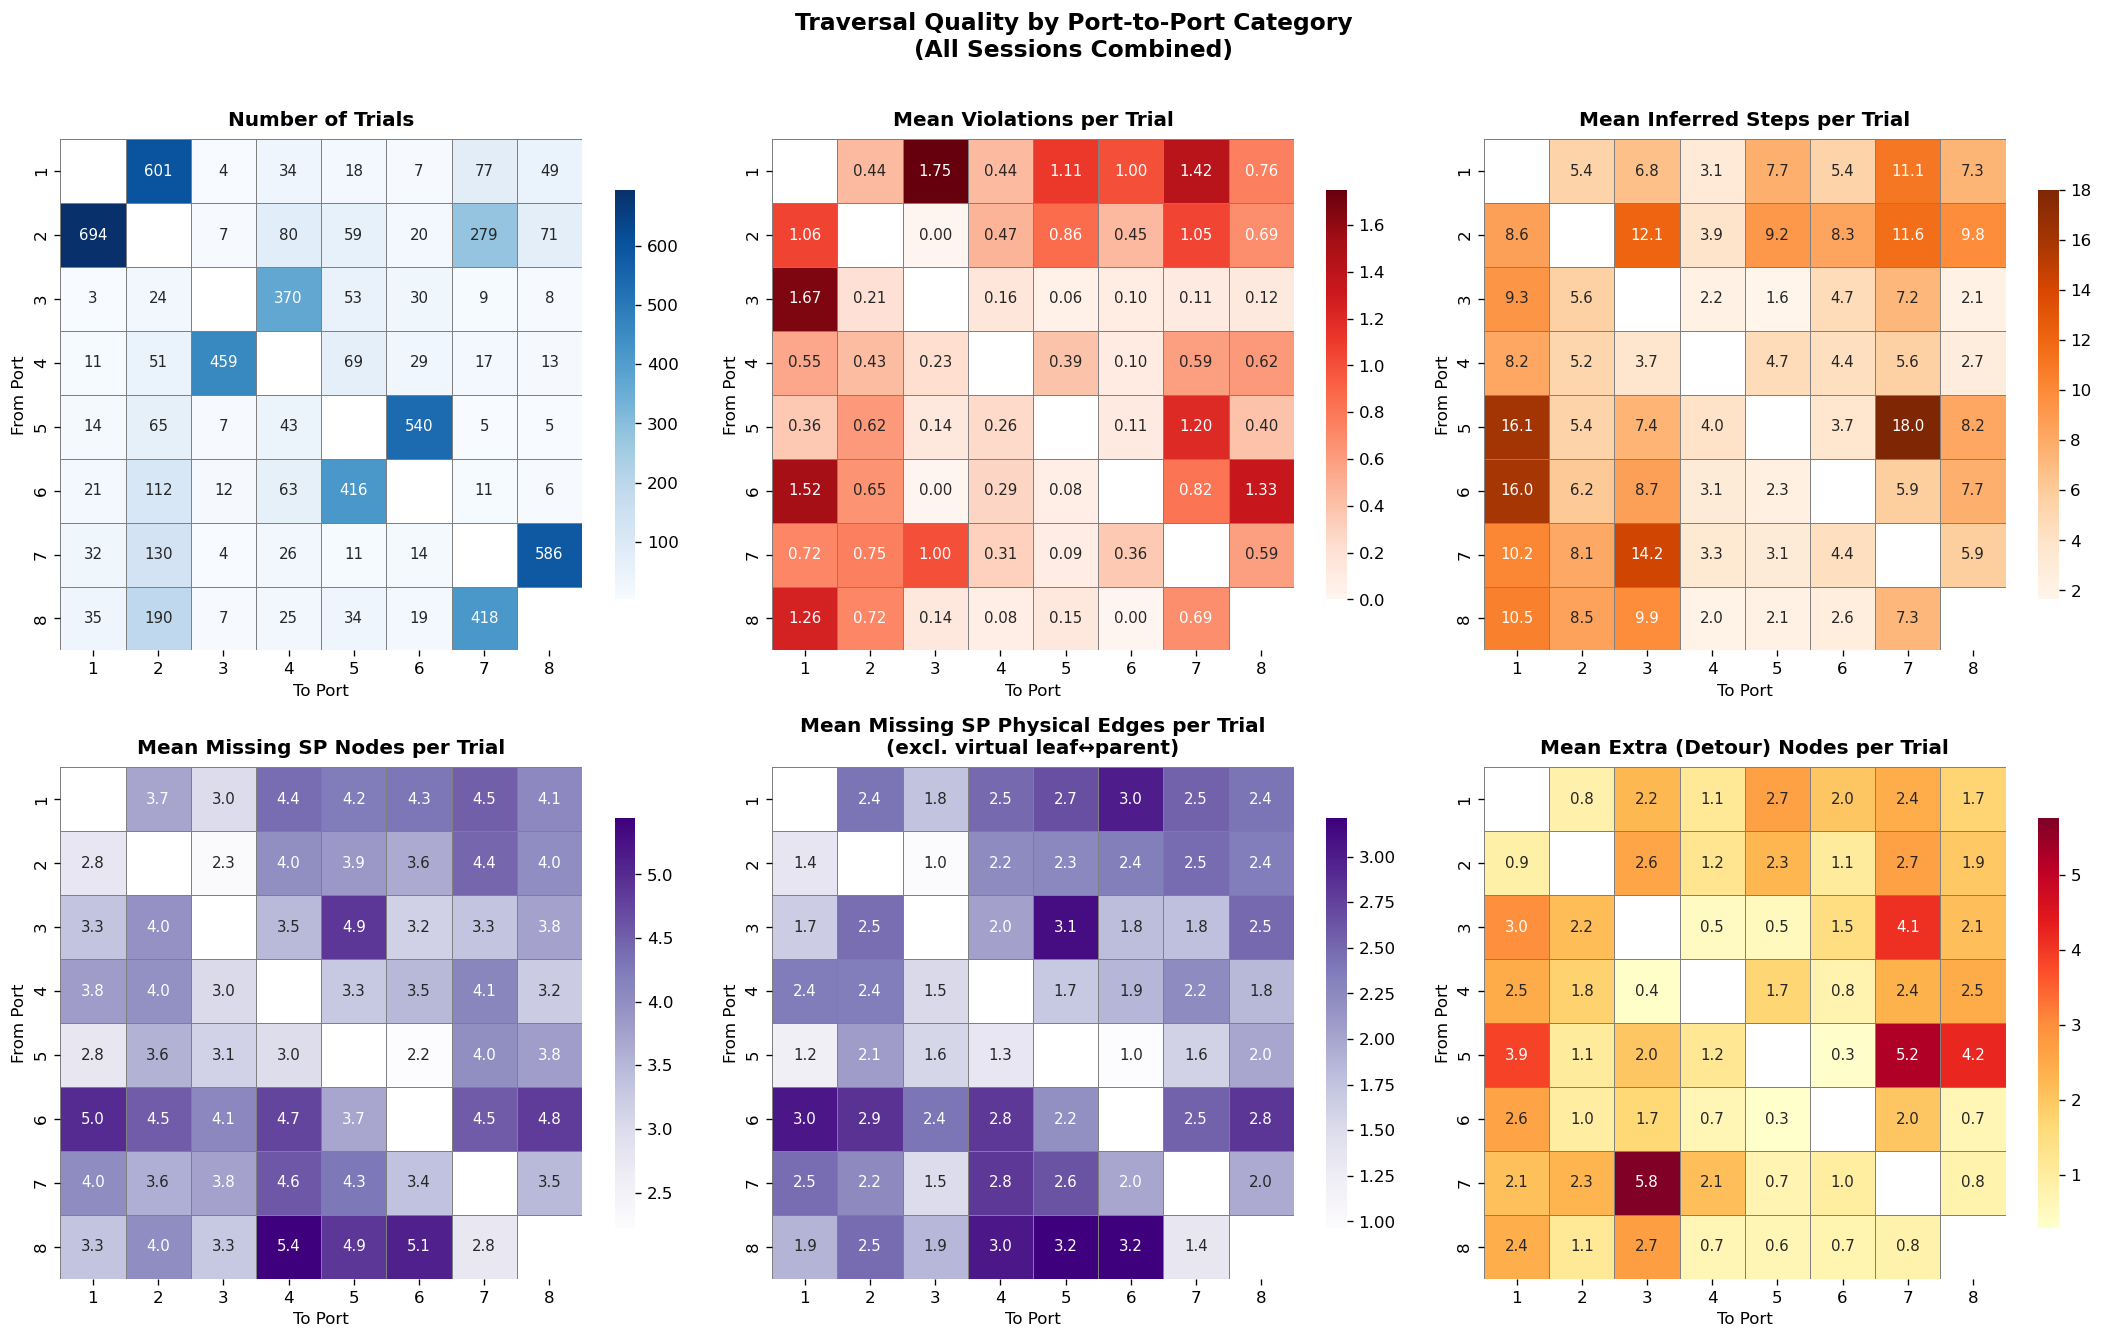

Saved: traversal_quality_heatmaps.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Traversal Quality by Port-to-Port Category\n(All Sessions Combined)', fontsize=14, fontweight='bold', y=1.01)

# 1. Number of trials
mat_trials = make_port_matrix(category_stats, 'n_trials')
plot_heatmap(mat_trials, 'Number of Trials', fmt='.0f', cmap='Blues', ax=axes[0, 0])

# 2. Mean violations per trial
mat_viol = make_port_matrix(category_stats, 'n_violations_mean')
plot_heatmap(mat_viol, 'Mean Violations per Trial', fmt='.2f', cmap='Reds', ax=axes[0, 1])

# 3. Mean inferred (corrected) steps per trial
mat_inf = make_port_matrix(category_stats, 'n_inferred_mean')
plot_heatmap(mat_inf, 'Mean Inferred Steps per Trial', fmt='.1f', cmap='Oranges', ax=axes[0, 2])

# 4. Mean missing nodes (shortest-path nodes not visited)
mat_miss_n = make_port_matrix(category_stats, 'n_missing_nodes_mean')
plot_heatmap(mat_miss_n, 'Mean Missing SP Nodes per Trial', fmt='.1f', cmap='Purples', ax=axes[1, 0])

# 5. Mean missing physical (regular) edges — virtual edges excluded, tracked separately
mat_miss_e = make_port_matrix(category_stats, 'n_missing_regular_edges_mean')
plot_heatmap(mat_miss_e, 'Mean Missing SP Physical Edges per Trial\n(excl. virtual leaf↔parent)', fmt='.1f', cmap='Purples', ax=axes[1, 1])

# 6. Mean extra (detour) nodes per trial
mat_extra = make_port_matrix(category_stats, 'n_extra_nodes_mean')
plot_heatmap(mat_extra, 'Mean Extra (Detour) Nodes per Trial', fmt='.1f', cmap='YlOrRd', ax=axes[1, 2])

plt.tight_layout()
plt.savefig(BASE_DIR / 'traversal_quality_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: traversal_quality_heatmaps.png')

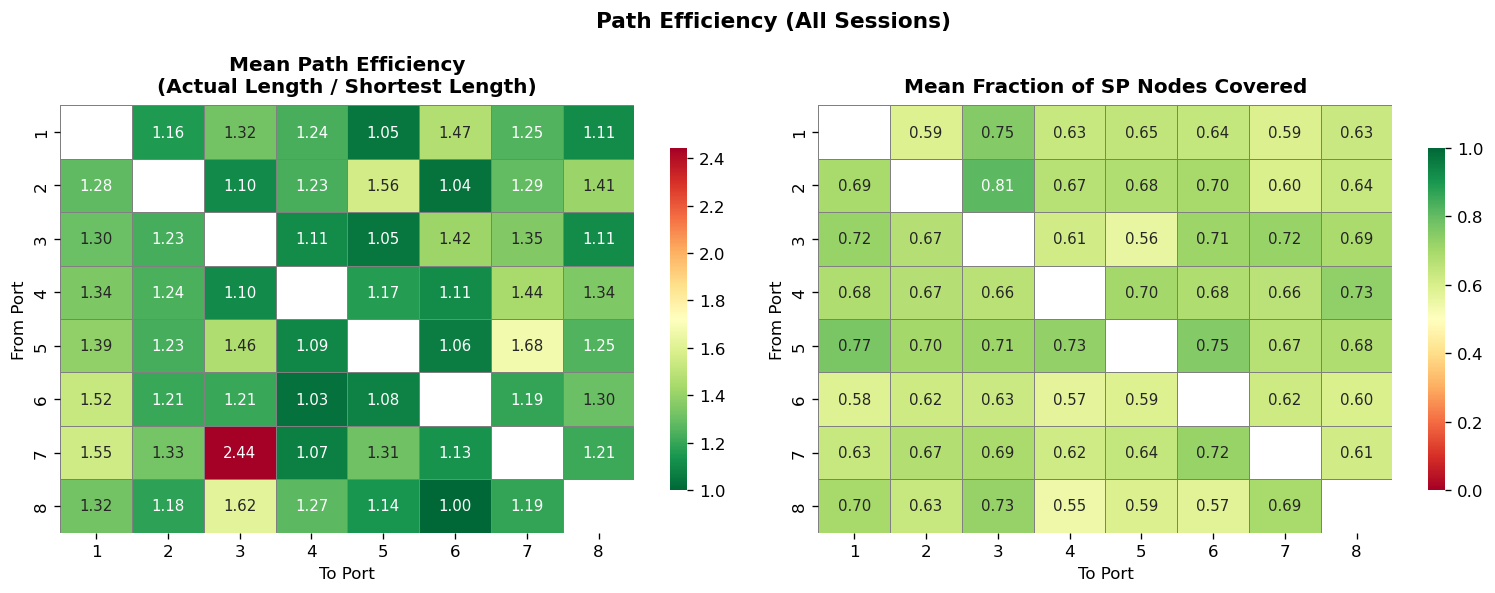

Saved: path_efficiency_heatmaps.png


In [ ]:
# Path efficiency heatmap (only if path_efficiency is available)
if 'path_efficiency_mean' in category_stats.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Path Efficiency (All Sessions)', fontsize=13, fontweight='bold')

    mat_eff = make_port_matrix(category_stats, 'path_efficiency_mean')
    plot_heatmap(mat_eff, 'Mean Path Efficiency\n(Actual Length / Shortest Length)', fmt='.2f',
                 cmap='RdYlGn_r', ax=axes[0], vmin=1.0)

    # Fraction of shortest-path nodes covered
    mat_cov = make_port_matrix(category_stats, 'frac_sp_nodes_covered_mean')
    if mat_cov.isna().all().all():
        mat_cov = make_port_matrix(category_stats, 'frac_sp_nodes_covered')
    plot_heatmap(mat_cov, 'Mean Fraction of SP Nodes Covered', fmt='.2f',
                 cmap='RdYlGn', ax=axes[1], vmin=0, vmax=1)

    plt.tight_layout()
    plt.savefig(BASE_DIR / 'path_efficiency_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: path_efficiency_heatmaps.png')
else:
    print('path_efficiency column not available — skipping efficiency heatmap.')

## 8. Violation Type Breakdown

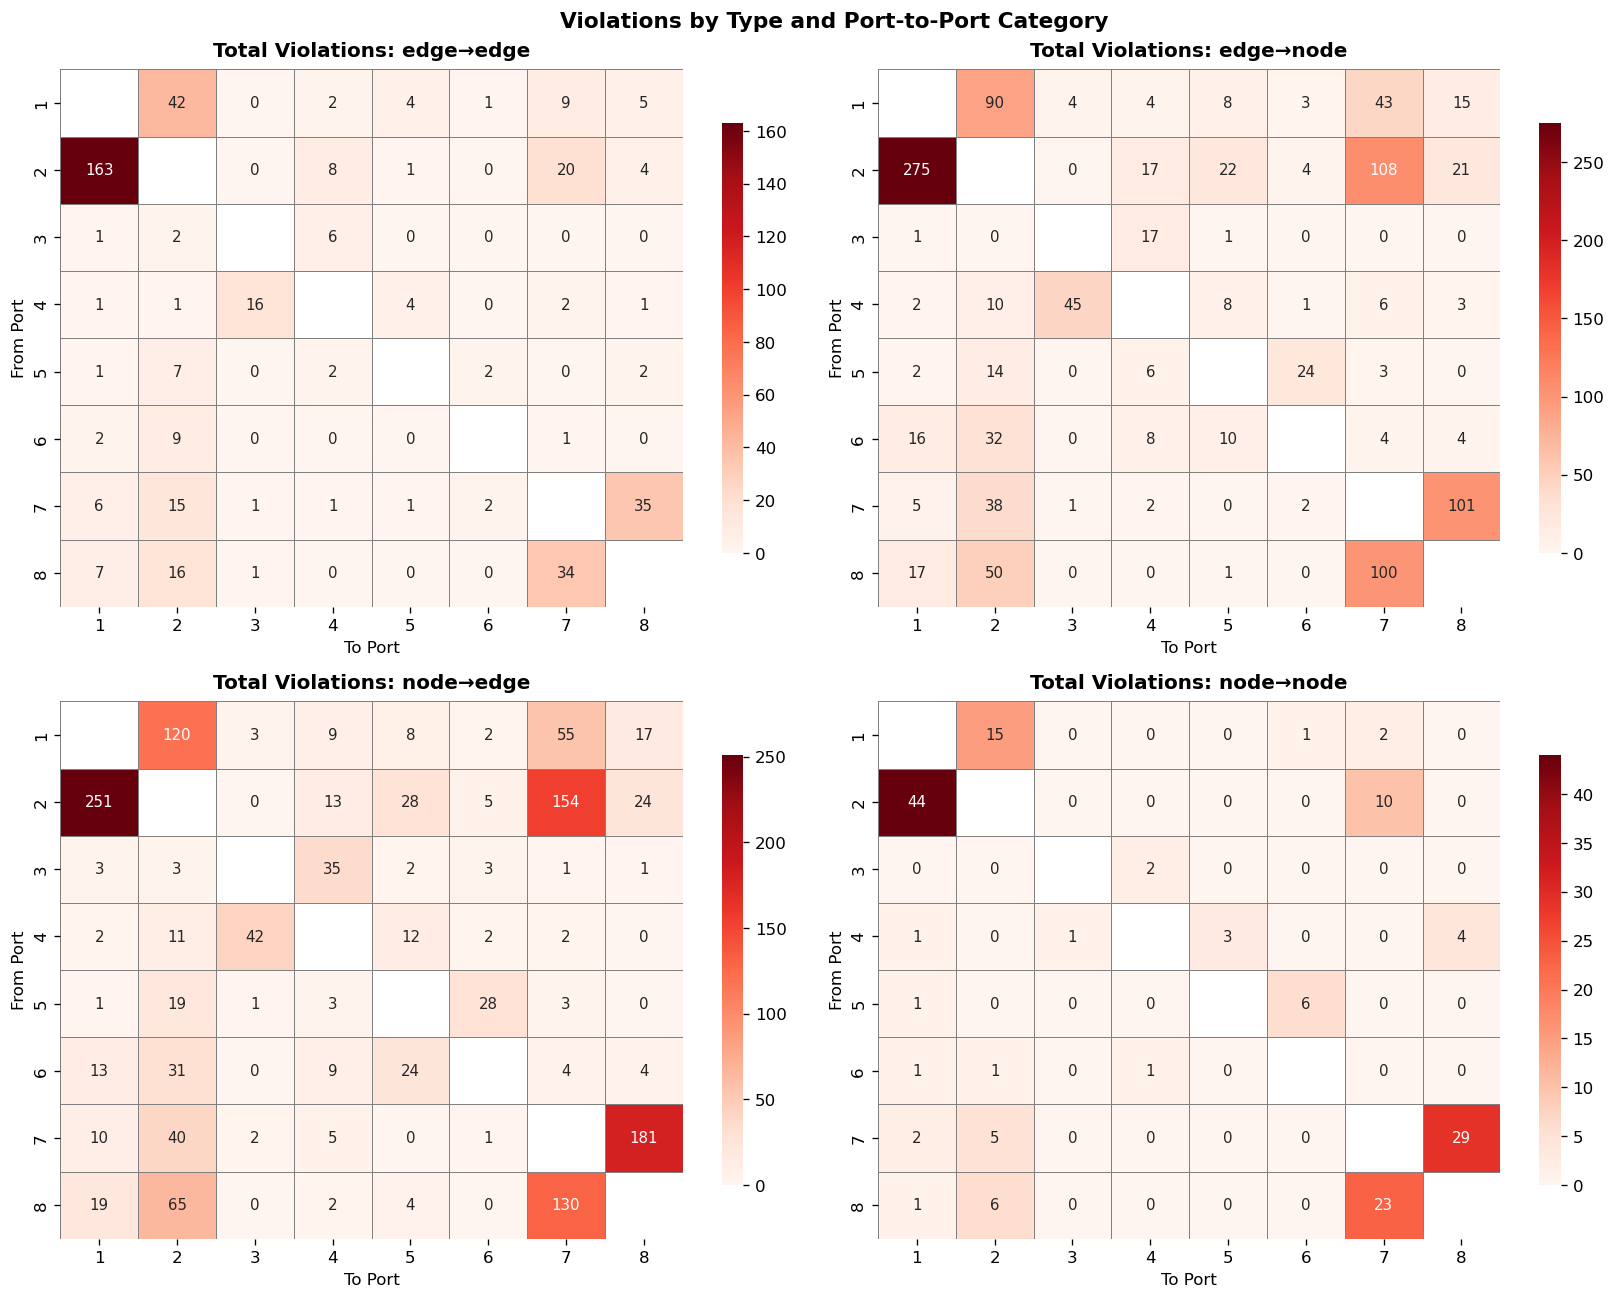

Saved: violation_types_heatmaps.png


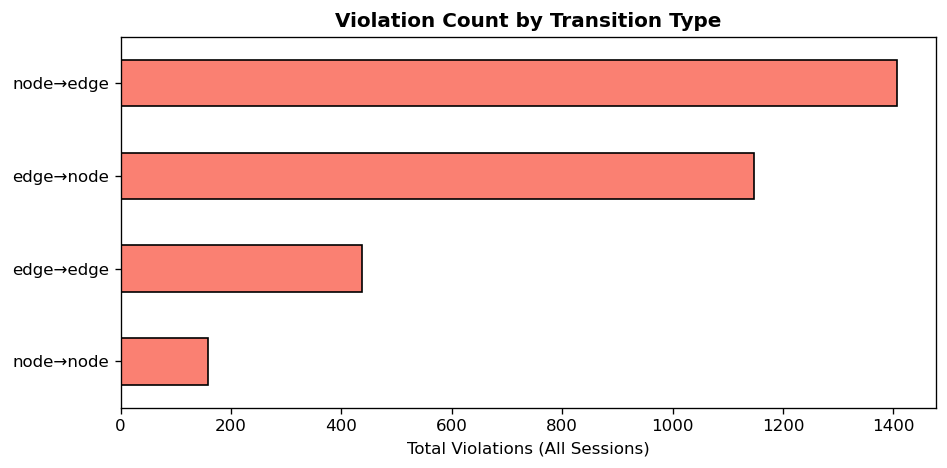

In [ ]:
viol_type_cols = [c for c in category_stats.columns if c.startswith('viol_') and c.endswith('_sum')]

if viol_type_cols:
    # Summarize violation types across all port pairs
    type_totals = category_stats[['port_from', 'port_to', 'n_trials'] + viol_type_cols].copy()
    type_totals['path_category'] = type_totals.apply(
        lambda r: f'Port{int(r.port_from)}→Port{int(r.port_to)}', axis=1)

    viol_type_labels = [c.replace('viol_', '').replace('_sum', '') for c in viol_type_cols]

    # Per-type heatmaps
    n_types = len(viol_type_cols)
    ncols = min(n_types, 2)
    nrows = (n_types + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * 5.5))
    axes = np.array(axes).flatten()
    fig.suptitle('Violations by Type and Port-to-Port Category', fontsize=13, fontweight='bold')

    for i, (col, label) in enumerate(zip(viol_type_cols, viol_type_labels)):
        mat = make_port_matrix(category_stats, col)
        plot_heatmap(mat, f'Total Violations: {label}', fmt='.0f', cmap='Reds', ax=axes[i])

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(BASE_DIR / 'violation_types_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: violation_types_heatmaps.png')

    # Overall violation type bar chart
    fig, ax = plt.subplots(figsize=(8, 4))
    type_sums = category_stats[viol_type_cols].sum()
    type_sums.index = viol_type_labels
    type_sums.sort_values(ascending=True).plot.barh(ax=ax, color='salmon', edgecolor='black')
    ax.set_xlabel('Total Violations (All Sessions)')
    ax.set_title('Violation Count by Transition Type', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No per-type violation columns found.')

## 9. Path Type Distribution (Direct vs Indirect)

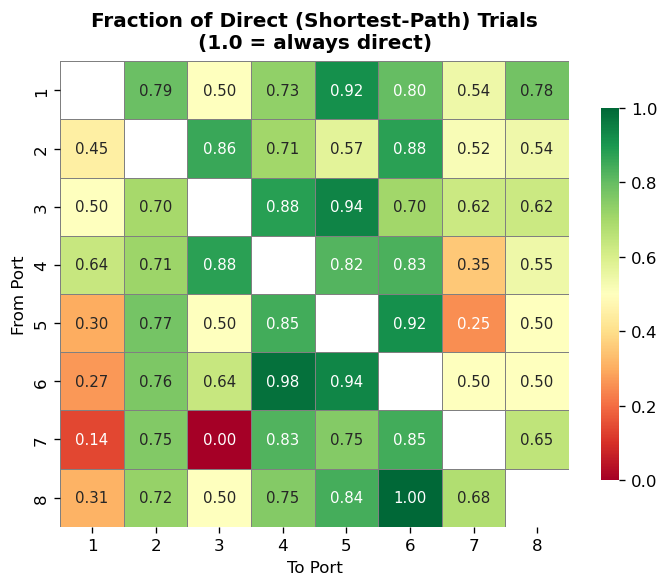

Saved: direct_path_fraction_heatmap.png


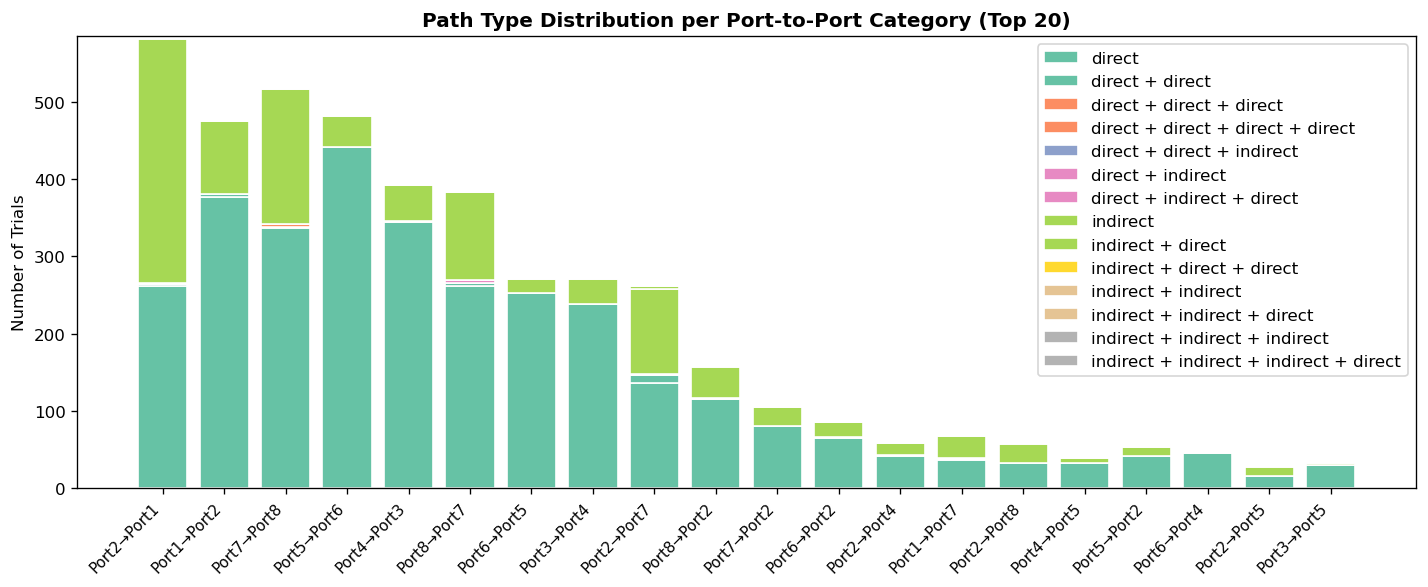

In [ ]:
path_type_cols = [c for c in category_stats.columns if c.startswith('path_type_')]

if path_type_cols:
    # Fraction of direct paths per category
    cs = category_stats.copy()
    total_path = cs[path_type_cols].sum(axis=1)
    for c in path_type_cols:
        cs[c + '_frac'] = cs[c] / total_path.replace(0, np.nan)

    direct_col = next((c for c in path_type_cols if 'direct' in c.lower() and 'indirect' not in c.lower()), None)
    if direct_col:
        mat_direct = make_port_matrix(cs, direct_col + '_frac')
        fig, ax = plt.subplots(figsize=(6, 5))
        plot_heatmap(mat_direct, 'Fraction of Direct (Shortest-Path) Trials\n(1.0 = always direct)', fmt='.2f',
                     cmap='RdYlGn', ax=ax, vmin=0, vmax=1)
        plt.tight_layout()
        plt.savefig(BASE_DIR / 'direct_path_fraction_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: direct_path_fraction_heatmap.png')

    # Stacked bar chart by category
    cs_sorted = cs.sort_values('n_trials', ascending=False).head(20)
    cs_sorted['cat'] = cs_sorted.apply(lambda r: f'Port{int(r.port_from)}→Port{int(r.port_to)}', axis=1)
    count_cols = [c for c in path_type_cols if cs_sorted[c].sum() > 0]
    if count_cols:
        fig, ax = plt.subplots(figsize=(12, 5))
        bot = np.zeros(len(cs_sorted))
        colors = plt.cm.Set2(np.linspace(0, 1, len(count_cols)))
        for col, color in zip(count_cols, colors):
            label = col.replace('path_type_', '')
            vals = cs_sorted[col].fillna(0).values
            ax.bar(cs_sorted['cat'], vals, bottom=bot, label=label, color=color, edgecolor='white')
            bot += vals
        ax.set_xticklabels(cs_sorted['cat'], rotation=45, ha='right', fontsize=9)
        ax.set_ylabel('Number of Trials')
        ax.set_title('Path Type Distribution per Port-to-Port Category (Top 20)', fontweight='bold')
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print('No path_type columns found — path type analysis skipped.')

## 10. Session-Level Trends

In [ ]:
session_stats = valid_trials.groupby('session').agg(
    n_trials=('trial_idx', 'count'),
    total_violations=('n_violations', 'sum'),
    mean_violations_per_trial=('n_violations', 'mean'),
    total_inferred=('n_inferred', 'sum'),
    mean_inferred_per_trial=('n_inferred', 'mean'),
    mean_missing_nodes=('n_missing_nodes', 'mean'),
    mean_missing_regular_edges=('n_missing_regular_edges', 'mean'),
    mean_missing_virtual_edges=('n_missing_virtual_edges', 'mean'),
    mean_extra_nodes=('n_extra_nodes', 'mean'),
    mean_frac_sp_covered=('frac_sp_nodes_covered', 'mean'),
).round(2)

if 'path_efficiency' in valid_trials.columns:
    eff = valid_trials.groupby('session')['path_efficiency'].mean().round(2)
    session_stats = session_stats.join(eff.rename('mean_path_efficiency'))

print('Session-level summary:')
print(session_stats.to_string())

Session-level summary:
            n_trials  total_violations  mean_violations_per_trial  total_inferred  mean_inferred_per_trial  mean_missing_nodes  mean_missing_regular_edges  mean_missing_virtual_edges  mean_extra_nodes  mean_frac_sp_covered  mean_path_efficiency
session                                                                                                                                                                                                                                             
09_09_2025       418               269                       0.64            1817                     4.35                3.34                        1.96                        0.89              0.76                  0.65                  1.13
10_09_2025       534               229                       0.43            2135                     4.00                2.99                        1.60                        0.85              0.43                  0.68                  1.

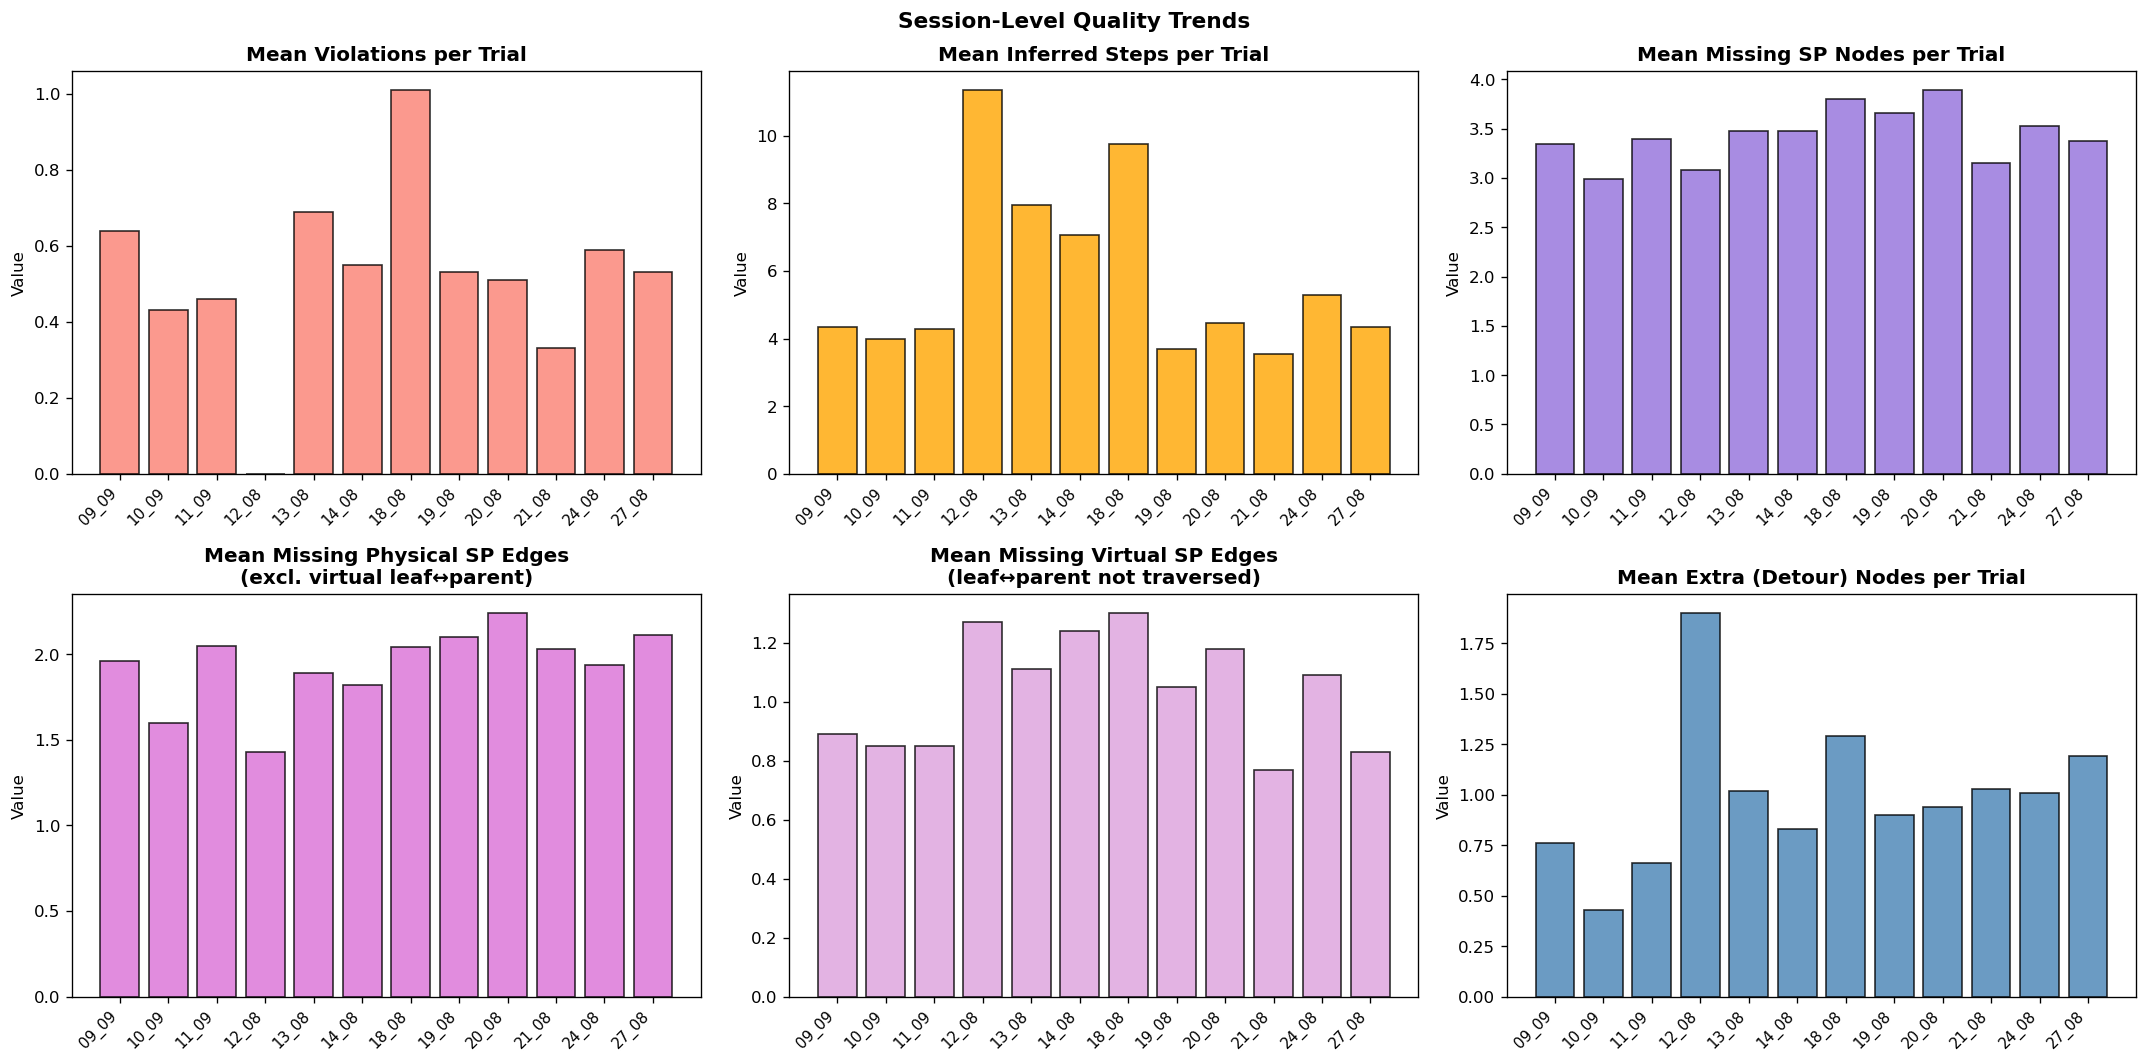

Saved: session_quality_trends.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Session-Level Quality Trends', fontsize=13, fontweight='bold')

sessions_ordered = sorted(session_stats.index)
x = range(len(sessions_ordered))
xticks_labels = [s.replace('_2025', '').replace('_2026', '') for s in sessions_ordered]

def bar_session(ax, col, title, color):
    vals = [session_stats.loc[s, col] if s in session_stats.index and col in session_stats.columns else 0
            for s in sessions_ordered]
    ax.bar(x, vals, color=color, edgecolor='black', alpha=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(xticks_labels, rotation=45, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Value')

bar_session(axes[0, 0], 'mean_violations_per_trial', 'Mean Violations per Trial', 'salmon')
bar_session(axes[0, 1], 'mean_inferred_per_trial', 'Mean Inferred Steps per Trial', 'orange')
bar_session(axes[0, 2], 'mean_missing_nodes', 'Mean Missing SP Nodes per Trial', 'mediumpurple')
bar_session(axes[1, 0], 'mean_missing_regular_edges', 'Mean Missing Physical SP Edges\n(excl. virtual leaf↔parent)', 'orchid')
bar_session(axes[1, 1], 'mean_missing_virtual_edges', 'Mean Missing Virtual SP Edges\n(leaf↔parent not traversed)', 'plum')
bar_session(axes[1, 2], 'mean_extra_nodes', 'Mean Extra (Detour) Nodes per Trial', 'steelblue')

plt.tight_layout()
plt.savefig(BASE_DIR / 'session_quality_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: session_quality_trends.png')

## 11. Detailed Per-Category Table
Full summary table sorted by total violations, showing all quality metrics per port-to-port pair.

In [ ]:
summary_table = category_stats.copy()
summary_table['path_category'] = summary_table.apply(
    lambda r: f'Port{int(r.port_from)}→Port{int(r.port_to)}', axis=1
)

display_cols = ['path_category', 'n_trials',
                'n_violations_sum', 'n_violations_mean',
                'n_inferred_mean',
                'n_missing_nodes_mean',
                'n_missing_regular_edges_mean', 'n_missing_virtual_edges_mean',
                'n_extra_nodes_mean', 'frac_sp_nodes_covered_mean']

if 'path_efficiency_mean' in summary_table.columns:
    display_cols.append('path_efficiency_mean')

path_type_frac_cols = [c for c in summary_table.columns if 'path_type_' in c and 'frac' in c]
display_cols += path_type_frac_cols
display_cols = [c for c in display_cols if c in summary_table.columns]

out = summary_table[display_cols].sort_values('n_violations_sum', ascending=False)
out = out.round(3)
print('Full category summary (sorted by total violations):')
print(out.to_string(index=False))

out.to_csv(BASE_DIR / 'traversal_quality_by_port_pair.csv', index=False)
print('\nSaved: traversal_quality_by_port_pair.csv')

Full category summary (sorted by total violations):
path_category  n_trials  n_violations_sum  n_violations_mean  n_inferred_mean  n_missing_nodes_mean  n_missing_regular_edges_mean  n_missing_virtual_edges_mean  n_extra_nodes_mean  frac_sp_nodes_covered_mean  path_efficiency_mean
  Port2→Port1       694               733              1.056            8.620                 2.769                         1.369                         0.994               0.859                       0.692                 1.280
  Port7→Port8       586               346              0.590            5.892                 3.469                         1.962                         1.189               0.773                       0.615                 1.212
  Port2→Port7       279               292              1.047           11.559                 4.437                         2.480                         1.441               2.652                       0.597                 1.285
  Port8→Port7       418     

## 12. Top Problem Port Pairs

Top 10 Most Problematic Port-to-Port Paths:
path_category  n_trials  problem_score  n_violations_mean  n_inferred_mean  n_missing_nodes_mean  n_extra_nodes_mean
  Port5→Port7         5          0.831              1.200           18.000                 4.000               5.200
  Port6→Port1        21          0.783              1.524           15.952                 5.000               2.619
  Port7→Port3         4          0.763              1.000           14.250                 3.750               5.750
  Port1→Port7        77          0.669              1.416           11.065                 4.506               2.442
  Port3→Port1         3          0.651              1.667            9.333                 3.333               3.000
  Port2→Port7       279          0.629              1.047           11.559                 4.437               2.652
  Port8→Port1        35          0.585              1.257           10.514                 3.343               2.429
  Port1→Port3       

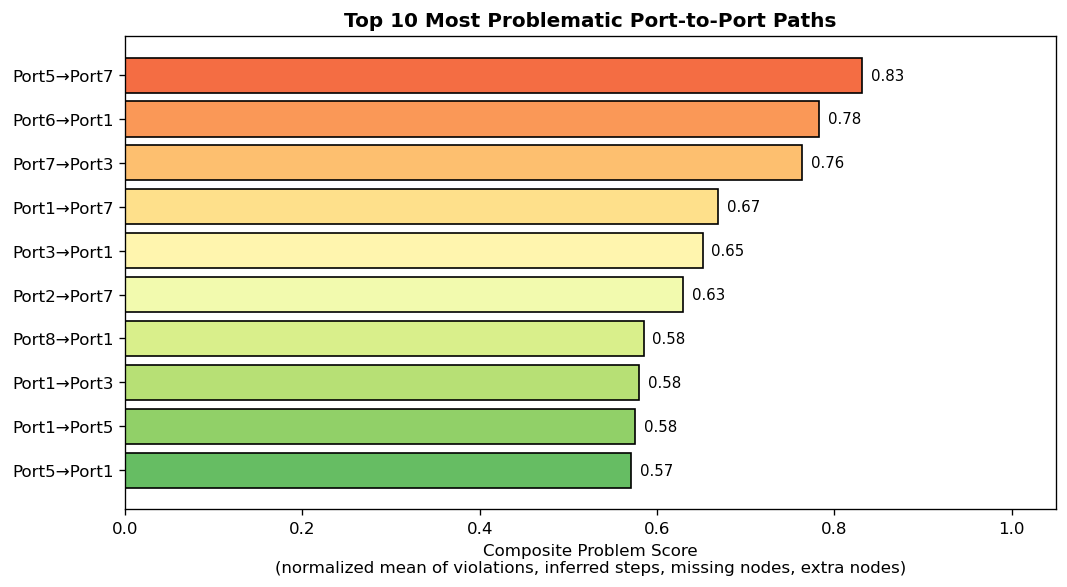

Saved: top_problem_pairs.png


In [ ]:
# Composite problem score: normalized sum of key issue metrics
norm_cols = ['n_violations_mean', 'n_inferred_mean', 'n_missing_nodes_mean', 'n_extra_nodes_mean']
norm_cols = [c for c in norm_cols if c in summary_table.columns]

for c in norm_cols:
    col_max = summary_table[c].max()
    summary_table[c + '_norm'] = summary_table[c] / col_max if col_max > 0 else 0

norm_cols_final = [c + '_norm' for c in norm_cols if c + '_norm' in summary_table.columns]
if norm_cols_final:
    summary_table['problem_score'] = summary_table[norm_cols_final].mean(axis=1)
    top_problems = summary_table.nlargest(10, 'problem_score')[['path_category', 'n_trials', 'problem_score'] + norm_cols]
    print('Top 10 Most Problematic Port-to-Port Paths:')
    print(top_problems.round(3).to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 5))
    top10 = summary_table.nlargest(10, 'problem_score').sort_values('problem_score')
    colors_map = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top10)))
    bars = ax.barh(top10['path_category'], top10['problem_score'], color=colors_map, edgecolor='black')
    ax.set_xlabel('Composite Problem Score\n(normalized mean of violations, inferred steps, missing nodes, extra nodes)')
    ax.set_title('Top 10 Most Problematic Port-to-Port Paths', fontweight='bold')
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, top10['problem_score']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'top_problem_pairs.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: top_problem_pairs.png')

## 13. Summary: Violation Examples per Category
Show actual violation transition types for the most problematic port pairs.

In [ ]:
# Collect all violations with their port categories across all sessions
all_viol_records = []
for session_name, data in sessions.items():
    reward = data['reward'].sort_values('trial_idx').reset_index(drop=True)
    reward['port_from'] = reward['reward_port'].shift(1)
    reward['port_to'] = reward['reward_port']
    reward['path_category'] = reward.apply(
        lambda r: f'Port{int(r.port_from)}→Port{int(r.port_to)}'
        if pd.notna(r.port_from) and r.port_from != r.port_to else None, axis=1
    )
    trial_to_cat = reward.set_index('trial_idx')['path_category'].to_dict()

    viol = data['viol'].copy()
    frame_to_trial = data['frame_to_trial']
    viol['trial_idx'] = viol['from_frame'].map(frame_to_trial)
    viol['path_category'] = viol['trial_idx'].map(trial_to_cat)
    viol['viol_type'] = viol['from_type'] + '→' + viol['to_type']
    viol['session'] = session_name
    all_viol_records.append(viol)

all_viols = pd.concat(all_viol_records, ignore_index=True)
all_viols_valid = all_viols[all_viols['path_category'].notna()]

print(f'Total categorized violations: {len(all_viols_valid)}')
print(f'Uncategorized: {all_viols["path_category"].isna().sum()}')
print()

pivot = all_viols_valid.groupby(['path_category', 'viol_type']).size().unstack(fill_value=0)
pivot['Total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('Total', ascending=False)

print('Violations by Path Category and Type:')
print(pivot.to_string())
pivot.to_csv(BASE_DIR / 'violations_by_category_and_type.csv')
print('\nSaved: violations_by_category_and_type.csv')

Total categorized violations: 2895
Uncategorized: 316

Violations by Path Category and Type:
viol_type      edge→edge  edge→node  node→edge  node→node  Total
path_category                                                   
Port2→Port1          149        248        222         40    659
Port7→Port8           33         99        175         28    335
Port8→Port7           30         92        125         22    269
Port2→Port7           20         97        136          9    262
Port1→Port2           35         72        103         11    221
Port8→Port2           15         50         65          6    136
Port1→Port7            8         39         54          2    103
Port7→Port2           15         38         39          5     97
Port4→Port3           13         35         35          1     84
Port6→Port2            9         31         30          1     71
Port5→Port6            2         22         26          6     56
Port3→Port4            6         15         33          2     

In [71]:
# Expected shortest paths + violation examples per type and category

def _parse_cat(cat):
    parts = cat.replace('Port', '').split('→')
    return int(parts[0]), int(parts[1])

# ── 1. Expected shortest paths ────────────────────────────────────────────────────────────────────
observed_cats = set(valid_trials['path_category'].dropna().unique())

print("EXPECTED SHORTEST PATHS (Port7=R55, Port8=R59 -- August sessions)\n")
print(f"{'Category':<18} {'Len':>3}  Path")
print("-" * 90)
for (pf, pt), path in sorted(sp_before_switch.items()):
    cat = f'Port{pf}→Port{pt}'
    if cat in observed_cats:
        path_str = ' -> '.join(str(n) for n in path)
        print(f"{cat:<18} {len(path)-1:>3}  {path_str}")

print()
print("Port7/8 swap for Sep 07-11 sessions (Port7=R59, Port8=R55):")
for (pf, pt), path_b in sorted(sp_after_switch.items()):
    path_a = sp_before_switch.get((pf, pt), [])
    cat = f'Port{pf}→Port{pt}'
    if path_b != path_a and cat in observed_cats:
        path_str = ' -> '.join(str(n) for n in path_b)
        print(f"  {cat:<18} {len(path_b)-1:>3}  {path_str}")

# ── 2. Violation examples per type ──────────────────────────────────────────────────────────────────────────────
print("\n\n" + "=" * 90)
print("VIOLATION EXAMPLES  (top 3 path categories, up to 2 examples each, per violation type)")
print("=" * 90)

for viol_type in ['node→edge', 'edge→node', 'edge→edge', 'node→node']:
    subset = all_viols_valid[all_viols_valid['viol_type'] == viol_type]
    if subset.empty:
        continue
    print(f"\n{'-'*90}")
    print(f"  {viol_type}  ({len(subset)} total violations across all sessions)")
    print(f"{'-'*90}")

    top_cats = subset['path_category'].value_counts().head(3).index
    for cat in top_cats:
        cat_sub = subset[subset['path_category'] == cat]
        pf, pt  = _parse_cat(cat)

        sess0 = cat_sub['session'].iloc[0]
        sp_for_sess = session_shortest_paths.get(sess0, {})
        expected_path = sp_for_sess.get((pf, pt), [])
        expected_str  = ' -> '.join(str(n) for n in expected_path) if expected_path else '(unavailable)'
        n_hops = len(expected_path) - 1 if expected_path else '?'

        print(f"\n  {cat}  [{len(cat_sub)} violations]")
        print(f"    Expected path (len={n_hops}): {expected_str}")
        print(f"    Examples:")
        for _, row in cat_sub.head(2).iterrows():
            tid = int(row['trial_idx']) if pd.notna(row['trial_idx']) else '?'
            print(f"      [{row['session']}  trial={tid}]  "
                  f"{row['from']} ({row['from_type']})  ->  {row['to']} ({row['to_type']})")


EXPECTED SHORTEST PATHS (Port7=R55, Port8=R59 -- August sessions)

Category           Len  Path
------------------------------------------------------------------------------------------
Port1→Port2          8  R522 -> R411 -> R35 -> R22 -> R11 -> R23 -> R36 -> R413 -> R526
Port1→Port3         11  R522 -> R411 -> R35 -> R22 -> R11 -> R0 -> L0 -> L10 -> L20 -> L31 -> L43 -> L56
Port1→Port4         11  R522 -> R411 -> R35 -> R22 -> R11 -> R0 -> L0 -> L10 -> L21 -> L32 -> L45 -> L510
Port1→Port5         11  R522 -> R411 -> R35 -> R22 -> R11 -> R0 -> L0 -> L11 -> L22 -> L35 -> L410 -> L521
Port1→Port6         11  R522 -> R411 -> R35 -> R22 -> R11 -> R0 -> L0 -> L11 -> L23 -> L36 -> L412 -> L525
Port1→Port7         10  R522 -> R411 -> R35 -> R22 -> R11 -> R0 -> R10 -> R20 -> R31 -> R42 -> R55
Port1→Port8         10  R522 -> R411 -> R35 -> R22 -> R11 -> R0 -> R10 -> R21 -> R32 -> R44 -> R59
Port2→Port1          8  R526 -> R413 -> R36 -> R23 -> R11 -> R22 -> R35 -> R411 -> R522
Port2→Port3   

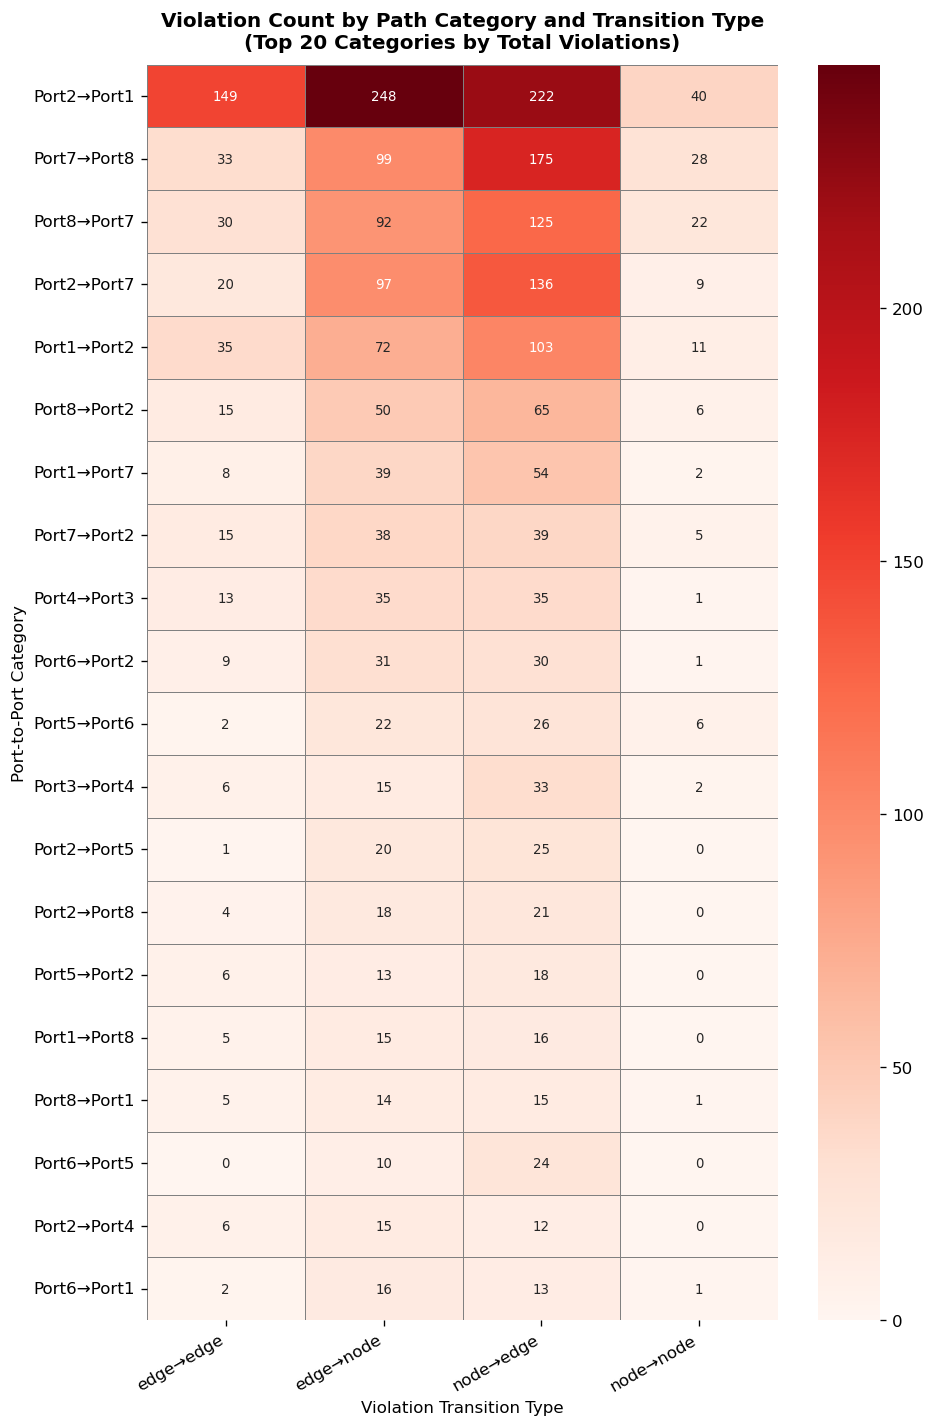

Saved: violation_type_by_category_heatmap.png


In [ ]:
# Heatmap: violations by (path_category × viol_type)
if len(pivot) > 0:
    type_cols = [c for c in pivot.columns if c != 'Total']
    if type_cols:
        top_cats = pivot['Total'].nlargest(20).index
        sub = pivot.loc[top_cats, type_cols]

        fig, ax = plt.subplots(figsize=(max(8, len(type_cols) * 2), min(14, len(top_cats) * 0.5 + 2)))
        sns.heatmap(sub, annot=True, fmt='.0f', cmap='Reds', ax=ax,
                    linewidths=0.5, linecolor='grey',
                    annot_kws={'size': 8})
        ax.set_title('Violation Count by Path Category and Transition Type\n(Top 20 Categories by Total Violations)',
                     fontweight='bold', pad=10)
        ax.set_xlabel('Violation Transition Type')
        ax.set_ylabel('Port-to-Port Category')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.savefig(BASE_DIR / 'violation_type_by_category_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: violation_type_by_category_heatmap.png')